# Preparatory calculations for input parameters

In [3]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

In [4]:
global_dpath = '~/work/hist_sst/data/'

# Historical calculations

## Forcing (ERF)

In [6]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'
ds_erf = xr.open_dataset(global_dpath + path + fname)

In [ ]:
erf_total = ds_erf.to_array("agent").sum("agent")
erf_total.name = "ERF"
erf_total

In [10]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(1850,2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")

CPU times: user 627 ms, sys: 8.9 s, total: 9.52 s
Wall time: 13.8 s


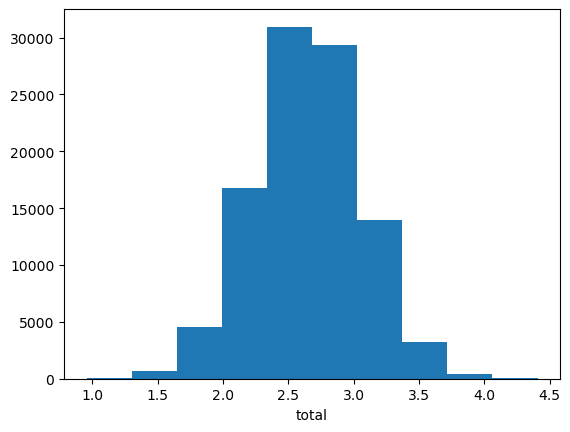

In [12]:
period_end = slice(2006,2024)
period_base = slice(1850,1900)
derf = (
    erf_total.sel(time=period_end ).mean(dim='time') - 
    erf_total.sel(time=period_base).mean(dim='time')
)

derf.plot.hist()
plt.show()

In [16]:
print(derf.quantile([0.05,0.50, 0.95]).values)
print(derf.std().values)
# derf.mean()

[1.97980555 2.65097938 3.31511532]
0.40630589084562474


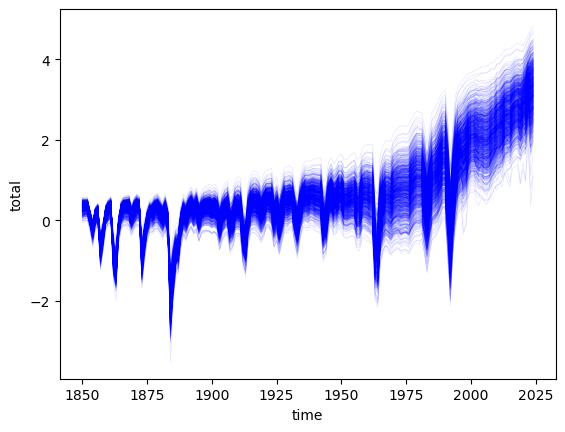

In [21]:
erf_total.isel(
    ensemble=np.random.choice(
        np.arange(len(erf_total.ensemble)), 
        size=1000, replace=False)
).plot.line(x='time',alpha=0.1,c='b',lw=0.5,add_legend=False)
plt.show()

## N (EEI): TOA imbalance

### IGCC

### CERES

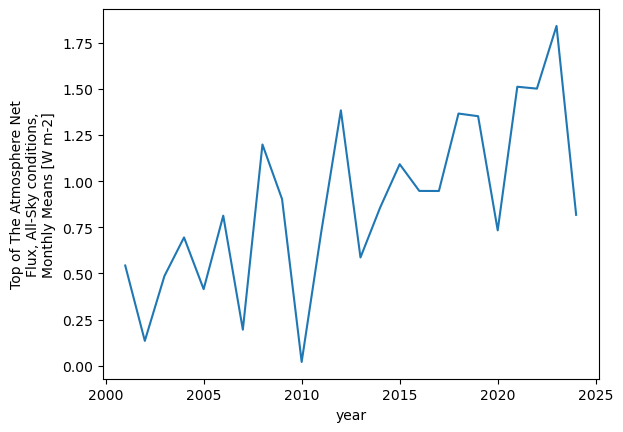

In [45]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01','2024-12-31')).groupby('time.year').mean()
ceres['gtoa_net_all_mon'].plot()


## Temperature

In [22]:
gmst_path = Path(global_dpath + "ar7-gmst-ensemble/sst_pseudo_ipcc.csv")

gmst_df = pd.read_csv(gmst_path, header=None)

gmst_ens = xr.DataArray(
    gmst_df.iloc[:, 1:].to_numpy(dtype="float32"),
    dims=("year", "ensemble"),
    coords={
        "year": gmst_df.iloc[:, 0].astype(int).to_numpy(),
        "ensemble": np.arange(gmst_df.shape[1] - 1),
    },
    name="gmst",
    attrs={"units": "degC", "baseline": "1850-1900"},
)

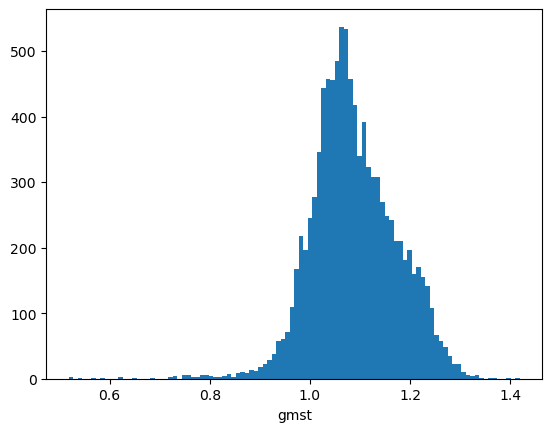

In [31]:
dT = (
    gmst_ens.sel(year=period_end ).mean(dim='year') - 
    gmst_ens.sel(year=period_base).mean(dim='year')
)

dT.plot.hist(bins=100)
plt.show()

In [30]:
print(dT.quantile([0.05,0.50, 0.95]).values)
print(dT.std().values)
print(dT.mean().values)

print(dT.quantile([0.05]).values - dT.quantile([0.5]).values)
print(dT.quantile([0.95]).values - dT.quantile([0.5]).values)

[0.96716547 1.07917619 1.2326984 ]
0.08415429
1.0879259
[-0.11201071]
[0.15352221]


In [39]:
## C25 and Thorne / AR7 have very similar 1sigma
print(np.sqrt(0.10**2+0.07**2))
print(np.sqrt(0.084**2+0.07**2))

0.12206555615733704
0.10934349546269317


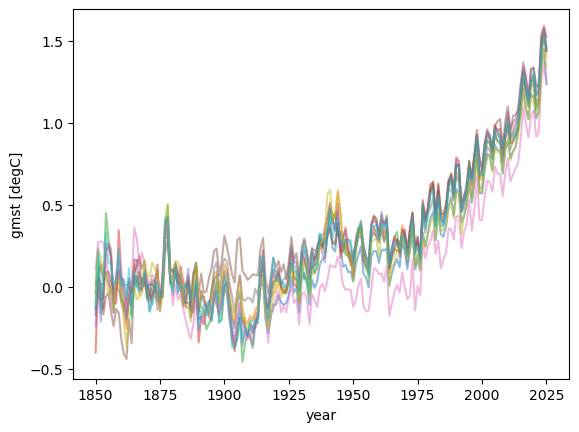

In [38]:
## confirm that errors are temporally correlated
gmst_ens.isel(ensemble=slice(10,20)).plot.line(
    x='year',alpha=0.5,add_legend=False)
plt.show()

# LGM

## Forcing (ERF)

In [8]:
lgm_ice = -3.2
lgm_veg = -1.1
lgm_aer = -1.0
lgm_n2o = -0.28
lgm_ch4 = -0.57
lgm_nonco2 = lgm_ice + lgm_veg + lgm_aer + lgm_ch4 + lgm_n2o
print(lgm_nonco2)

lgm_ice = (-3.2 - 2.1)/2 # reduction in forcing: Paleocalibr CESM2 and CESM1.2
# lgm_ice = -2.5
lgm_veg = -1.1
lgm_aer = -0.5 #-1.0
lgm_n2o = -0.28
lgm_ch4 = -0.57
lgm_nonco2 = lgm_ice + lgm_veg + lgm_aer + lgm_ch4 + lgm_n2o
print(lgm_nonco2)

sig_ice = 0.85*1.5 #T20 spread from PMIP3 and PMIP2 using APRP
sig_veg = 0.57*1.5 # 50% increase
sig_dust = 1. #0.94 kohler, 1.0 SW20
sig_dust = 1.46 # mahowald
sig_n2o = 0.10
sig_ch4 = 0.05
sig_nonco2 = (sig_ice**2 + sig_veg**2 + sig_dust**2 + sig_ch4**2 + sig_n2o**2)**0.5
sig_nonco2

-6.150000000000001
-5.1000000000000005


2.121497112889857